Importar librerías

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import shap
 
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.patches import Patch
import matplotlib.dates as mdates
from pathlib import Path
 
plt.style.use("seaborn-v0_8")

Cargar datasets

In [ ]:
PROJ_ROOT         = Path(r"C:\Users\jorge gonzalez\Documents\TFG\Proyecto")
DATA_FEATURES_DIR = PROJ_ROOT / "data" / "features" / "hotel_ttoo"
METRICS_DIR       = PROJ_ROOT / "models" / "metrics"
IMPORTANCE_DIR    = PROJ_ROOT / "models" / "importances"
PRED_DIR          = PROJ_ROOT / "models" / "predictions"
 
for d in [METRICS_DIR, IMPORTANCE_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [41]:
files = glob.glob(os.path.join(DATA_FEATURES_DIR, "*.parquet"))
dfs   = [pd.read_parquet(f) for f in files]
df    = pd.concat(dfs, ignore_index=True)
 
df["fecha"] = pd.to_datetime(df["fecha"], unit="ms")
df = df.sort_values(["hotel", "fecha"]).reset_index(drop=True).dropna()
df = pd.get_dummies(df, columns=["season"], drop_first=True)
 
print("Shape dataset limpio:", df.shape)
display(df.head(3))

Shape dataset limpio: (3038, 23)


,fecha,hotel,ocup_total,is_weekend,rn_AL,rn_AV,rn_B,rn_C,rn_EA,rn_EX,...,rn_L,rn_O,rn_T,rn_TH,rn_TR,rn_WEB,rn_WEL,season_spring,season_summer,season_winter
0,2023-01-01,HOTEL_1,0.510638,1,0.0,0.0,19.0,0.0,0.0,7.0,...,0.0,4.0,0.0,0.0,1.0,0.0,16.0,False,False,True
1,2023-01-02,HOTEL_1,0.659574,0,0.0,0.0,26.0,0.0,0.0,4.0,...,0.0,4.0,0.0,0.0,1.0,0.0,25.0,False,False,True
2,2023-01-03,HOTEL_1,0.627660,0,0.0,0.0,24.0,0.0,0.0,6.0,...,0.0,4.0,0.0,0.0,1.0,0.0,20.0,False,False,True


Selección de features causales (evitar fuga)

In [42]:
target    = "ocup_total"
drop_cols = ["fecha", "hotel", "ocup_total"]
 
def select_causal_features(df_cols):
    return [
        c for c in df_cols
        if c == "is_weekend"
        or c.startswith("season_")
        or c.startswith("rn_")
    ]

Funciones de métricas y ayuda

In [43]:
def compute_mape_safe(y_true, y_pred, eps=1e-8) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom  = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)
 
hotels = df["hotel"].unique()

Train / Test Split temporal


Entrenando XGBoost — Hotel: HOTEL_1


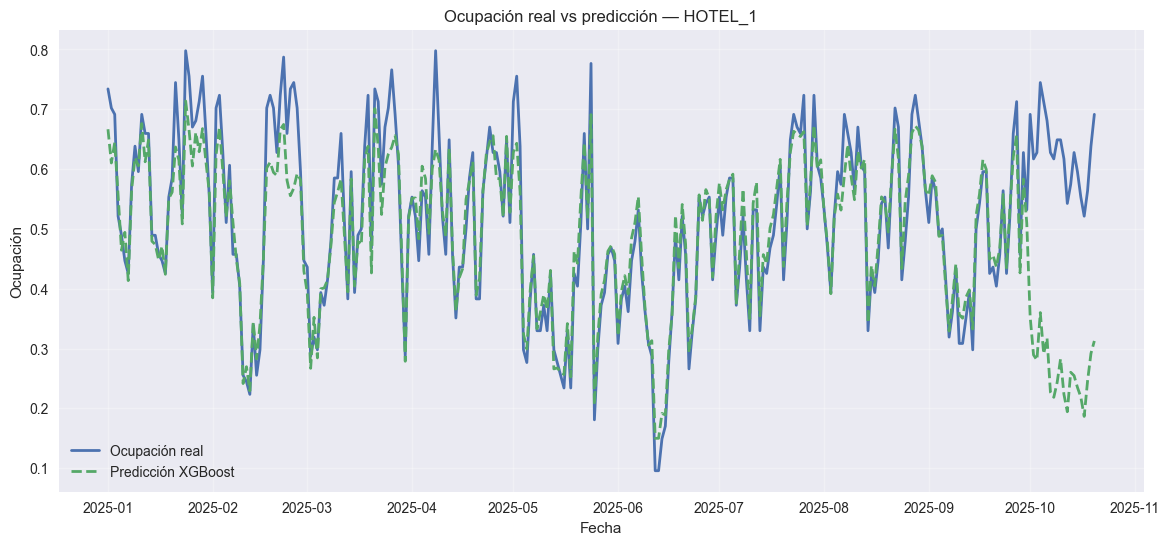

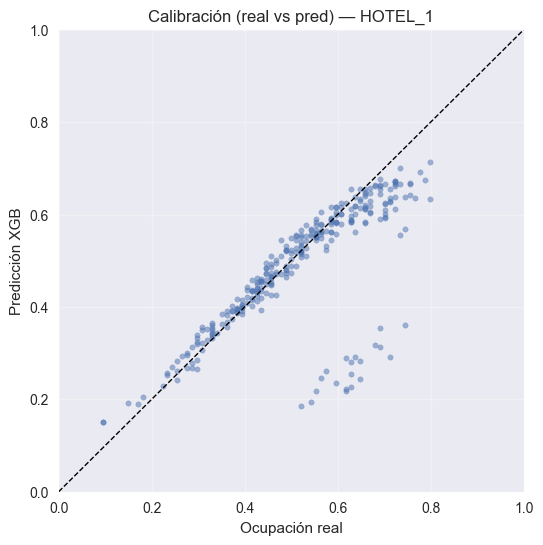

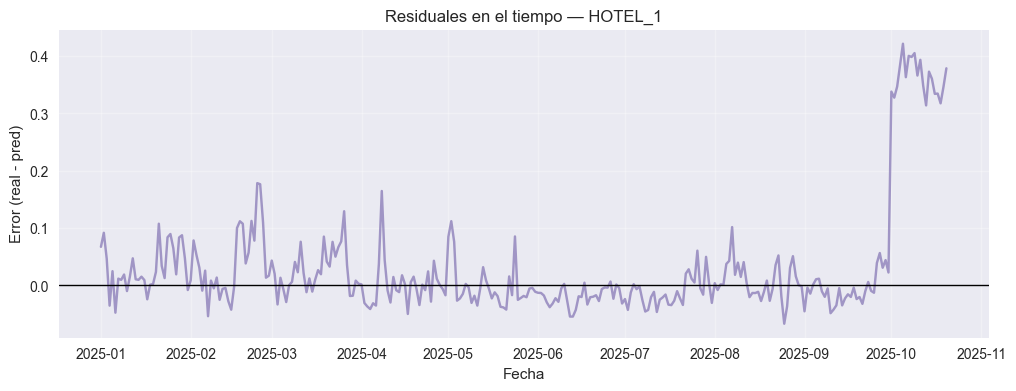

C:\Users\jorge gonzalez\AppData\Local\Temp\ipykernel_114608\2183999639.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="dow", y="abs_err", data=tmp, palette="Blues")


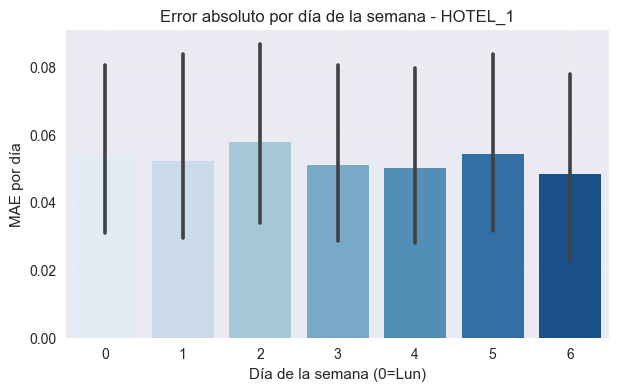


Entrenando XGBoost — Hotel: HOTEL_2


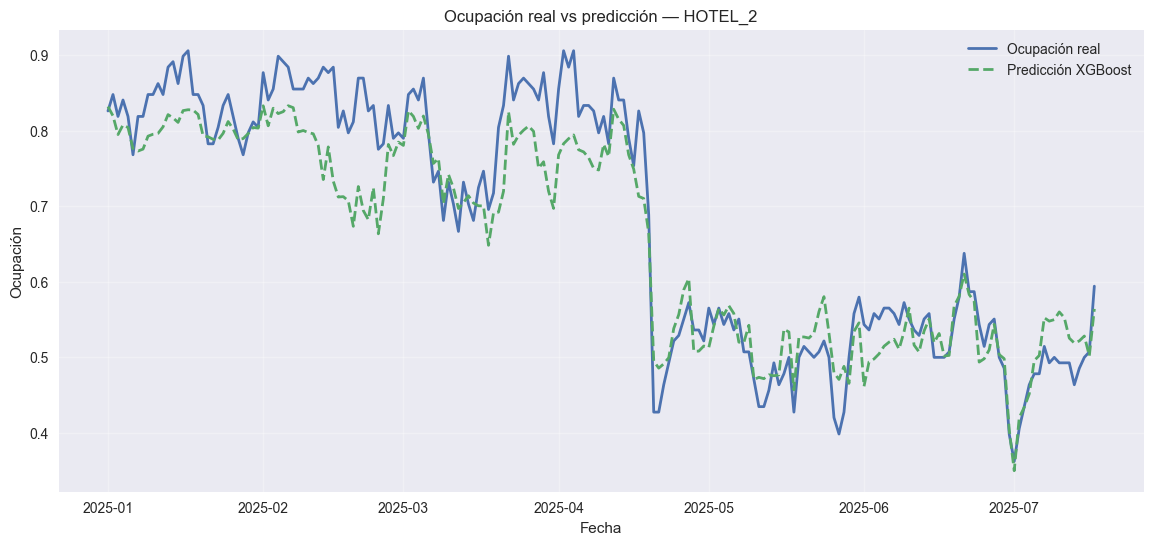

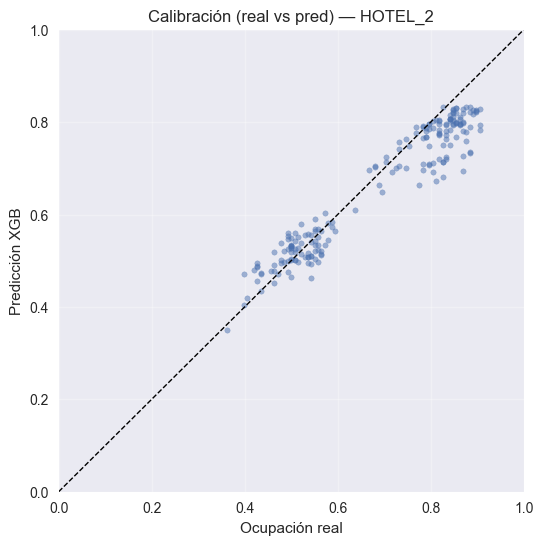

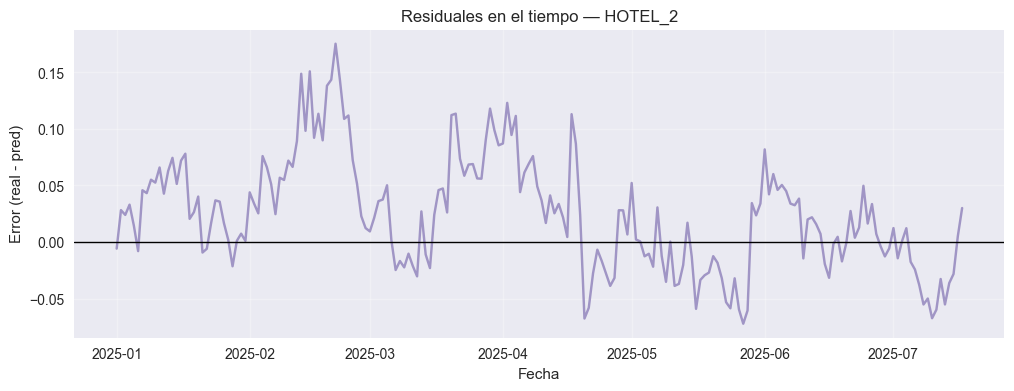

C:\Users\jorge gonzalez\AppData\Local\Temp\ipykernel_114608\2183999639.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="dow", y="abs_err", data=tmp, palette="Blues")


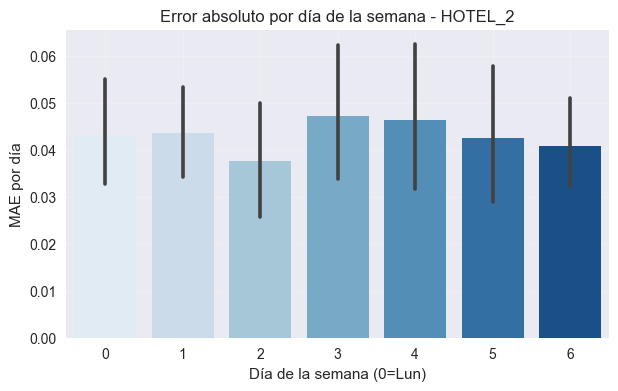


Entrenando XGBoost — Hotel: HOTEL_3


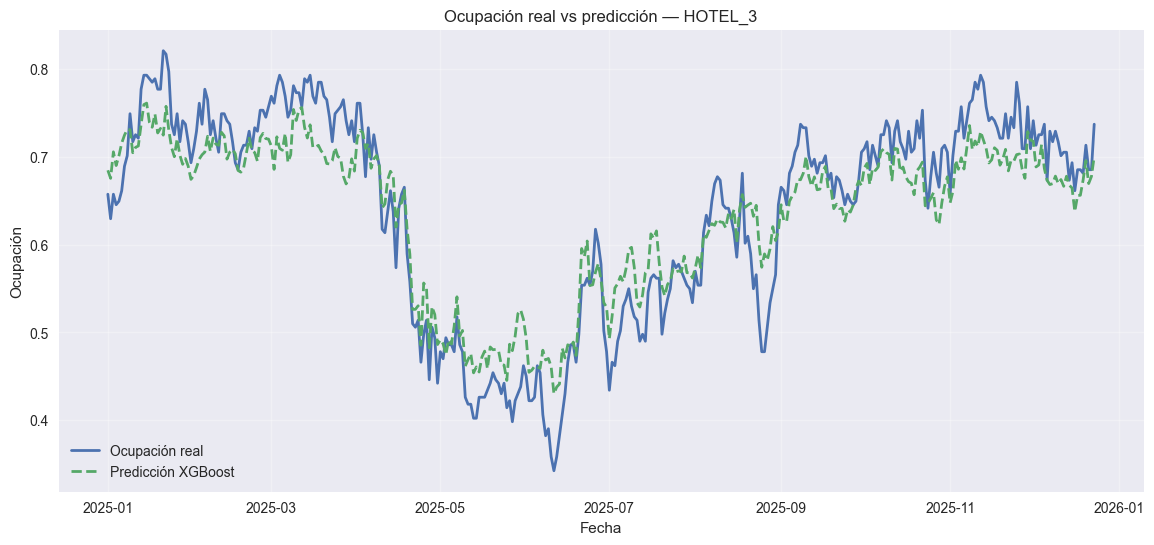

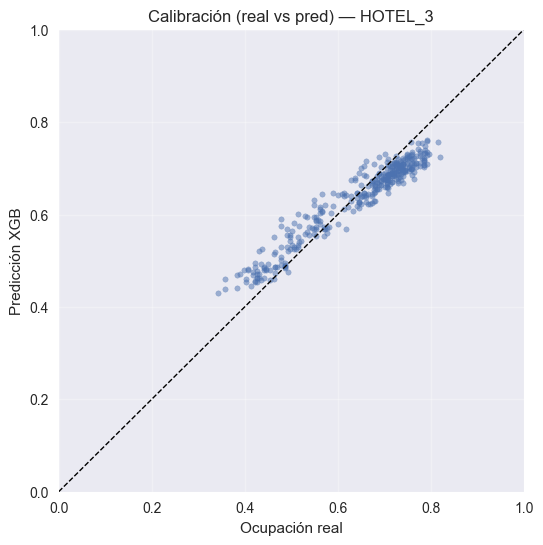

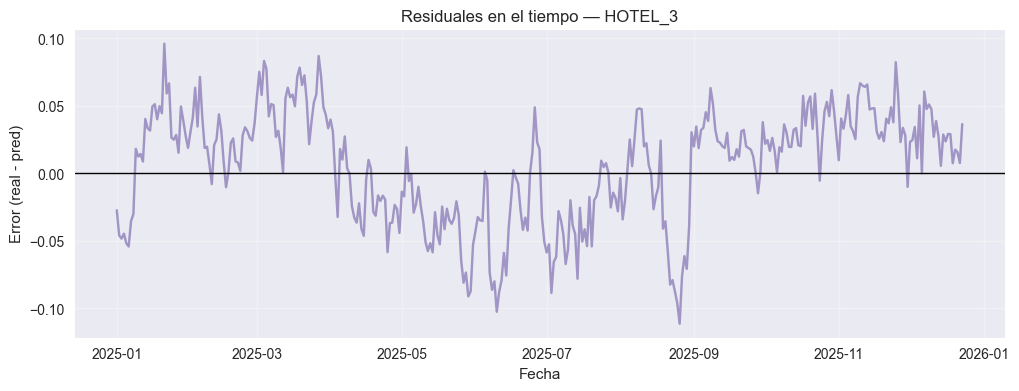

C:\Users\jorge gonzalez\AppData\Local\Temp\ipykernel_114608\2183999639.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="dow", y="abs_err", data=tmp, palette="Blues")


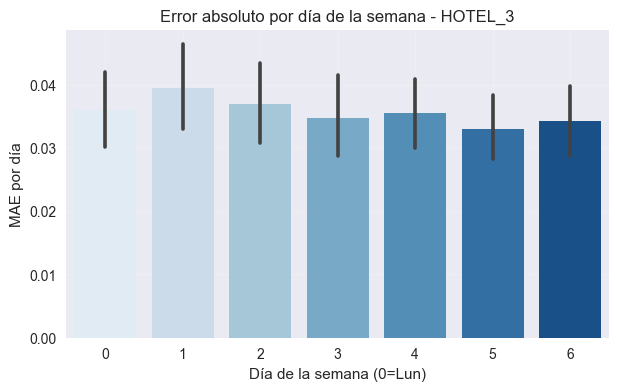

In [44]:
results            = []
xgb_importance_all = []
models_xgb         = {}
 
for hotel in hotels:
    print(f"\nEntrenando XGBoost — Hotel: {hotel}")
 
    df_h  = df[df["hotel"] == hotel].copy()
    train = df_h[df_h["fecha"] <  "2025-01-01"].copy()
    test  = df_h[df_h["fecha"] >= "2025-01-01"].copy()
 
    if len(test) == 0:
        print("Sin test para", hotel)
        continue
 
    feat_cols = [c for c in select_causal_features(train.columns) if c not in drop_cols]
    X_train, y_train = train[feat_cols], train[target]
    X_test,  y_test  = test[feat_cols],  test[target]
 
    model = XGBRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1,
        tree_method="hist", eval_metric="rmse"
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    models_xgb[hotel] = model
 
    pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = compute_mape_safe(y_test, pred)
 
    results.append({"hotel": hotel, "modelo": "XGBoost",
                    "MAE": mae, "RMSE": rmse, "MAPE": mape})
 
    fi = pd.Series(model.feature_importances_, index=feat_cols).sort_values(ascending=False)
    xgb_imp_h = fi.reset_index().rename(columns={"index": "feature", 0: "importance"})
    xgb_imp_h["hotel"] = hotel
    xgb_importance_all.append(xgb_imp_h)
 
    # Real vs Predicción
    plt.figure(figsize=(14, 6))
    plt.plot(test["fecha"], y_test, label="Ocupación real", lw=2)
    plt.plot(test["fecha"], pred,   label="Predicción XGBoost", lw=2, ls="--")
    plt.title(f"Ocupación real vs predicción — {hotel}")
    plt.xlabel("Fecha"); plt.ylabel("Ocupación")
    plt.grid(alpha=0.3); plt.legend(); plt.show()
 
    # Calibración
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, pred, alpha=0.5, s=15)
    lims = [0, 1]
    plt.plot(lims, lims, "k--", linewidth=1)
    plt.xlim(lims); plt.ylim(lims)
    plt.title(f"Calibración (real vs pred) — {hotel}")
    plt.xlabel("Ocupación real"); plt.ylabel("Predicción XGB")
    plt.grid(alpha=0.3); plt.show()
 
    # Residuales
    resid = y_test.values - pred
    plt.figure(figsize=(12, 4))
    plt.plot(test["fecha"], resid, color="C3", alpha=0.7)
    plt.axhline(0, color="k", lw=1)
    plt.title(f"Residuales en el tiempo — {hotel}")
    plt.xlabel("Fecha"); plt.ylabel("Error (real - pred)")
    plt.grid(alpha=0.3); plt.show()
 
    # Error por día de la semana
    tmp = test.copy()
    tmp["pred"]    = pred
    tmp["abs_err"] = np.abs(tmp["ocup_total"] - tmp["pred"])
    if "dow" not in tmp.columns:
        tmp["dow"] = tmp["fecha"].dt.dayofweek
 
    plt.figure(figsize=(7, 4))
    sns.barplot(x="dow", y="abs_err", data=tmp, palette="Blues")
    plt.title(f"Error absoluto por día de la semana - {hotel}")
    plt.xlabel("Día de la semana (0=Lun)"); plt.ylabel("MAE por día")
    plt.grid(alpha=0.2); plt.show()
 
xgb_results_df = pd.DataFrame(results).sort_values("hotel")

In [45]:
xgb_results_df.to_csv(METRICS_DIR / "xgb_results.csv", index=False)
print("Métricas XGBoost guardadas en:", METRICS_DIR / "xgb_results.csv")
display(xgb_results_df.groupby("hotel").head(10))

Métricas XGBoost guardadas en: C:\Users\jorge gonzalez\Documents\TFG\Proyecto_clean\models\metrics\xgb_results.csv


,hotel,modelo,MAE,RMSE,MAPE
0,HOTEL_1,XGBoost,0.052480,0.103318,9.551614
1,HOTEL_2,XGBoost,0.043035,0.055046,6.189086
2,HOTEL_3,XGBoost,0.035688,0.041940,5.939267


Predicciones

In [46]:
pred_rows = []
 
for hotel in hotels:
    df_h  = df[df["hotel"] == hotel].copy()
    train = df_h[df_h["fecha"] <  "2025-01-01"].copy()
    test  = df_h[df_h["fecha"] >= "2025-01-01"].copy()
 
    if len(test) == 0:
        continue
 
    feat_cols = [c for c in select_causal_features(train.columns) if c not in drop_cols]
    X_test, y_test = test[feat_cols], test[target]
 
    pred = models_xgb[hotel].predict(X_test)
 
    pred_rows.append(pd.DataFrame({
        "fecha": test["fecha"].values,
        "hotel": hotel, "modelo": "XGBoost",
        "y_real": y_test.values, "y_pred": pred
    }))
 
df_pred_xgb = pd.concat(pred_rows, ignore_index=True)
df_pred_xgb.to_parquet(PRED_DIR / "xgb_predictions.parquet", index=False)
print("✅ Predicciones XGBoost guardadas en:", PRED_DIR / "xgb_predictions.parquet")
df_pred_xgb.head()

✅ Predicciones XGBoost guardadas en: C:\Users\jorge gonzalez\Documents\TFG\Proyecto_clean\models\predictions\xgb_predictions.parquet


,fecha,hotel,modelo,y_real,y_pred
0,2025-01-01,HOTEL_1,XGBoost,0.734043,0.666609
1,2025-01-02,HOTEL_1,XGBoost,0.702128,0.610197
2,2025-01-03,HOTEL_1,XGBoost,0.691489,0.644644
3,2025-01-04,HOTEL_1,XGBoost,0.521277,0.556399
4,2025-01-05,HOTEL_1,XGBoost,0.489362,0.464397


SHAP - Influencia de variables por hotel (GLOBAL)

In [47]:
def xgb_importance_with_sign(model, X_test, top_k=15, hotel="",
                              sample_n=None, random_state=42):
    X_in = X_test
    if sample_n is not None and len(X_test) > sample_n:
        X_in = X_test.sample(sample_n, random_state=random_state)
 
    explainer = shap.TreeExplainer(model)
    sv        = explainer.shap_values(X_in)
 
    imp = (
        pd.DataFrame({
            "feature":    X_test.columns,
            "weight":     np.mean(np.abs(sv), axis=0),
            "sign_value": np.mean(sv, axis=0)
        })
        .assign(
            sign   = lambda d: np.where(d["sign_value"] >= 0, "positivo", "negativo"),
            method = "shap"
        )
        .sort_values("weight", ascending=False)
        .reset_index(drop=True)
    )
 
    # --- Gráfica con valores, leyenda y exportación PDF ---
    imp_top = imp.head(top_k).sort_values("weight")
    colors  = imp_top["sign"].map({"positivo": "#2ca02c", "negativo": "#d62728"}).values
 
    fig, ax = plt.subplots(figsize=(9, 0.4 * len(imp_top) + 3))
    bars = ax.barh(imp_top["feature"], imp_top["weight"], color=colors, edgecolor="none")
 
    # Valor al final de cada barra
    for bar, val in zip(bars, imp_top["weight"]):
        ax.text(
            bar.get_width() + imp_top["weight"].max() * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            va="center", ha="left", fontsize=9, color="#333333"
        )
 
    # Leyenda
    legend_elements = [
        Patch(facecolor="#2ca02c", label="Efecto positivo"),
        Patch(facecolor="#d62728", label="Efecto negativo"),
    ]
    ax.legend(handles=legend_elements, loc="lower right", fontsize=9, framealpha=0.8)
 
    ax.set_title(f"{hotel} — Importancia SHAP (XGBoost)", fontsize=12, pad=10, fontweight="bold")
    ax.set_xlabel("Importancia media (|SHAP|)", fontsize=10)
    ax.set_xlim(0, imp_top["weight"].max() * 1.25)
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
 
    plt.tight_layout()

 
    plt.show()
    return imp

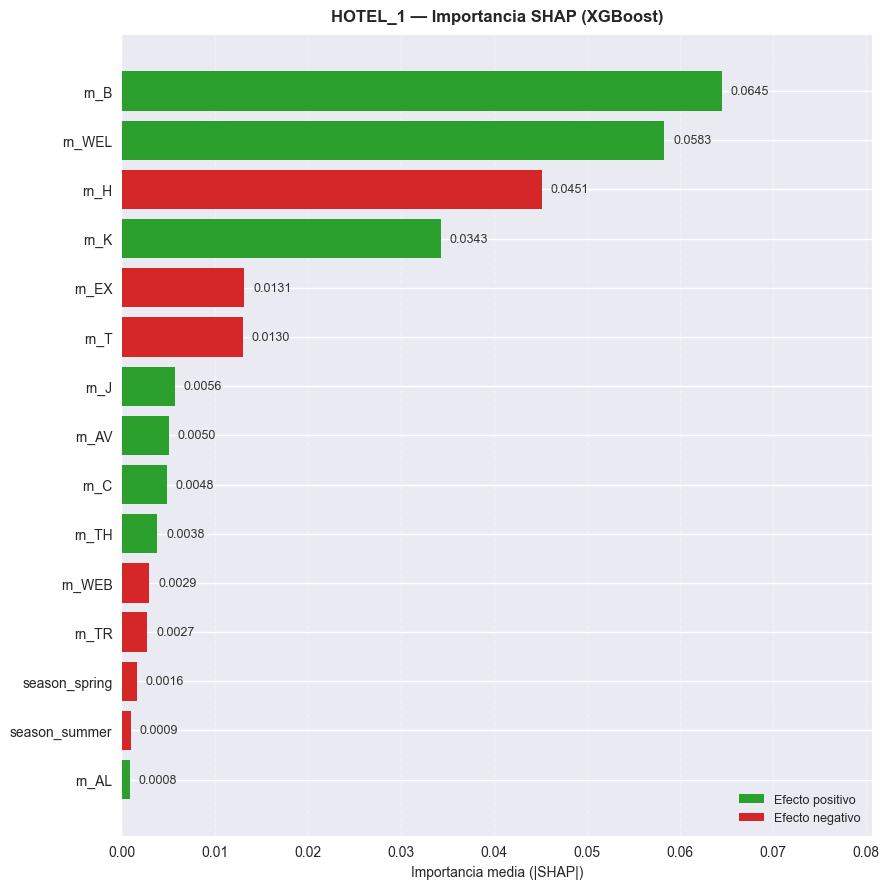

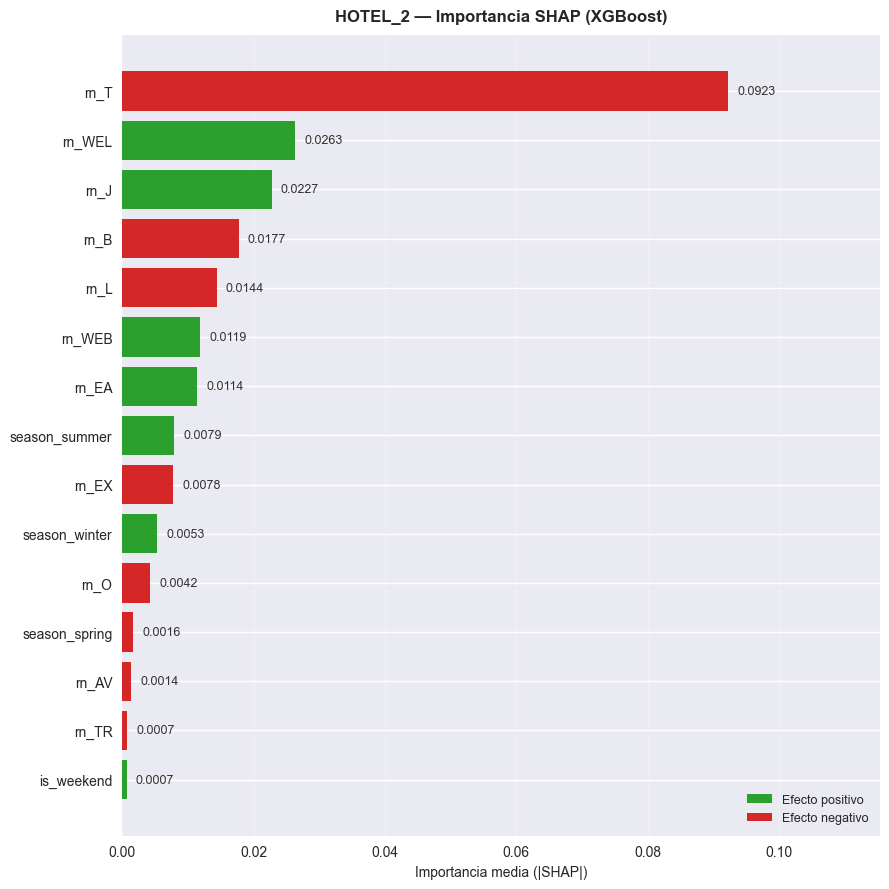

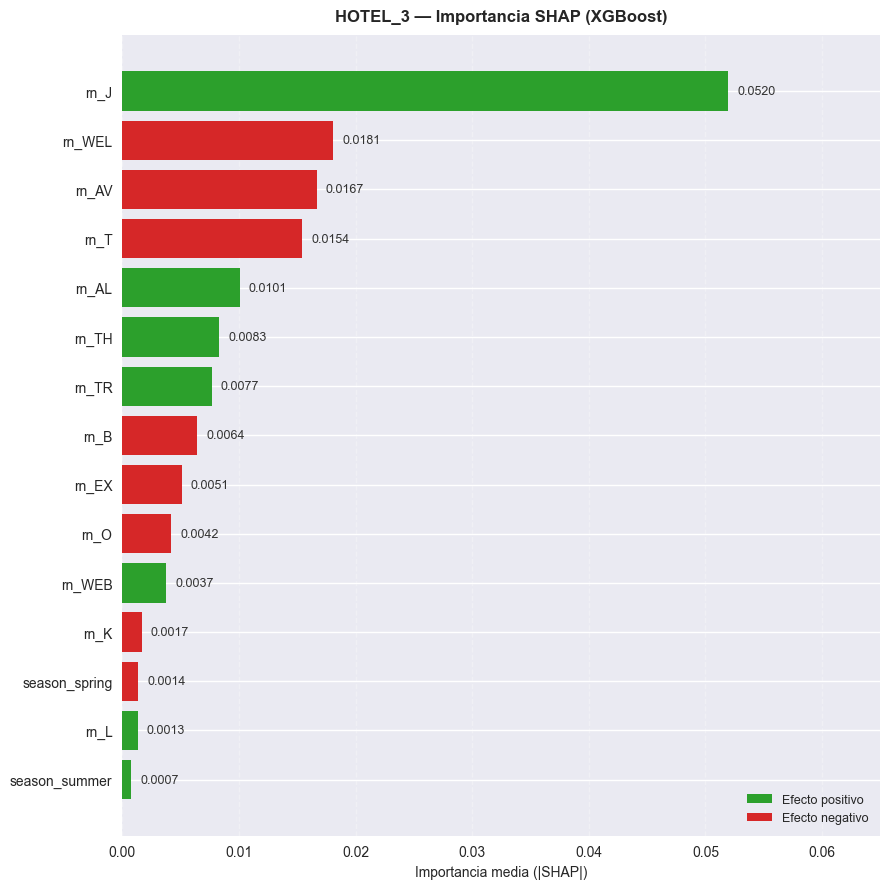

In [48]:
xgb_imp_all = []
 
for hotel in hotels:
    df_h  = df[df["hotel"] == hotel].copy()
    train = df_h[df_h["fecha"] <  "2025-01-01"]
    test  = df_h[df_h["fecha"] >= "2025-01-01"]
 
    feat_cols = [c for c in select_causal_features(train.columns) if c not in drop_cols]
    X_test    = test[feat_cols]
 
    imp_df        = xgb_importance_with_sign(
        models_xgb[hotel], X_test, top_k=15, hotel=hotel, sample_n=2000
    )
    imp_df["hotel"] = hotel
    xgb_imp_all.append(imp_df)
 
xgb_imp_all = (
    pd.concat(xgb_imp_all, ignore_index=True)
    .loc[:, ["hotel", "feature", "weight", "sign_value", "sign", "method"]]
    .sort_values(["hotel", "weight"], ascending=[True, False])
)

Exportación SHAP Global

In [49]:
xgb_imp_all.to_csv(IMPORTANCE_DIR / "xgb_importance_features.csv", index=False)
print("Importancias SHAP guardadas en:", IMPORTANCE_DIR / "xgb_importance_features.csv")
display(xgb_imp_all.groupby("hotel").head(10))

Importancias SHAP guardadas en: C:\Users\jorge gonzalez\Documents\TFG\Proyecto_clean\models\importances\xgb_importance_features.csv


,hotel,feature,weight,sign_value,sign,method
0,HOTEL_1,rn_B,0.064482,0.041968,positivo,shap
1,HOTEL_1,rn_WEL,0.058270,0.024320,positivo,shap
2,HOTEL_1,rn_H,0.045132,-0.035287,negativo,shap
3,HOTEL_1,rn_K,0.034282,0.008304,positivo,shap
4,HOTEL_1,rn_EX,0.013109,-0.009146,negativo,shap
5,HOTEL_1,rn_T,0.012955,-0.009477,negativo,shap
6,HOTEL_1,rn_J,0.005647,0.002461,positivo,shap
7,HOTEL_1,rn_AV,0.005005,0.002336,positivo,shap
8,HOTEL_1,rn_C,0.004802,0.002454,positivo,shap
9,HOTEL_1,rn_TH,0.003771,0.001386,positivo,shap


SHAP - Influencia de ttoo por hotel en la serie temporal 

In [50]:
rows = []
 
for hotel in hotels:
    print(f"\n📊 Calculando SHAP temporal histórico — {hotel}")
 
    df_h      = df[df["hotel"] == hotel].copy().sort_values("fecha")
    feat_cols = [c for c in select_causal_features(df_h.columns) if c not in drop_cols]
    X_shap    = df_h[feat_cols]
    y_real    = df_h["ocup_total"]
 
    explainer   = shap.TreeExplainer(models_xgb[hotel])
    shap_values = explainer.shap_values(X_shap)
 
    shap_df  = pd.DataFrame(shap_values, index=df_h.index, columns=X_shap.columns)
    ttoo_cols = [c for c in shap_df.columns
                 if c.startswith("rn_") or c.startswith("season_") or c == "is_weekend"]
 
    for channel in ttoo_cols:
        canal_name = channel.replace("rn_", "") if channel.startswith("rn_") else channel
        rows.append(pd.DataFrame({
            "fecha":      df_h["fecha"].values,
            "hotel":      hotel,
            "year":       df_h["fecha"].dt.year.values,
            "canal":      canal_name,
            "ocup_total": y_real.values,
            "shap_value": shap_df[channel].values,
            "family":     ("ttoo"      if channel.startswith("rn_") else
                           "season"    if channel.startswith("season_") else
                           "calendario")
        }))
 
df_shap_temporal = pd.concat(rows, ignore_index=True)
display(df_shap_temporal.head())


📊 Calculando SHAP temporal histórico — HOTEL_1

📊 Calculando SHAP temporal histórico — HOTEL_2

📊 Calculando SHAP temporal histórico — HOTEL_3


,fecha,hotel,year,canal,ocup_total,shap_value,family
0,2023-01-01,HOTEL_1,2023,is_weekend,0.510638,-0.000753,calendario
1,2023-01-02,HOTEL_1,2023,is_weekend,0.659574,0.000197,calendario
2,2023-01-03,HOTEL_1,2023,is_weekend,0.627660,0.000609,calendario
3,2023-01-04,HOTEL_1,2023,is_weekend,0.670213,0.000632,calendario
4,2023-01-05,HOTEL_1,2023,is_weekend,0.691489,0.003358,calendario


Exportación SHAP temporal

In [51]:
out_path = IMPORTANCE_DIR / "xgb_shap_temporal.csv"
df_shap_temporal.to_csv(out_path, index=False)
print("✅ SHAP temporal histórico XGBoost guardado en:", out_path)

✅ SHAP temporal histórico XGBoost guardado en: C:\Users\jorge gonzalez\Documents\TFG\Proyecto_clean\models\importances\xgb_shap_temporal.csv


Visualización - Utilidades de normalización

In [52]:
def shap_norm(values, low_q=15, high_q=85):
    vmin = np.percentile(values, low_q)
    vmax = np.percentile(values, high_q)
    if vmin < 0 < vmax:
        return TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    return Normalize(vmin=vmin, vmax=vmax)

Gráfica SHAP temporal

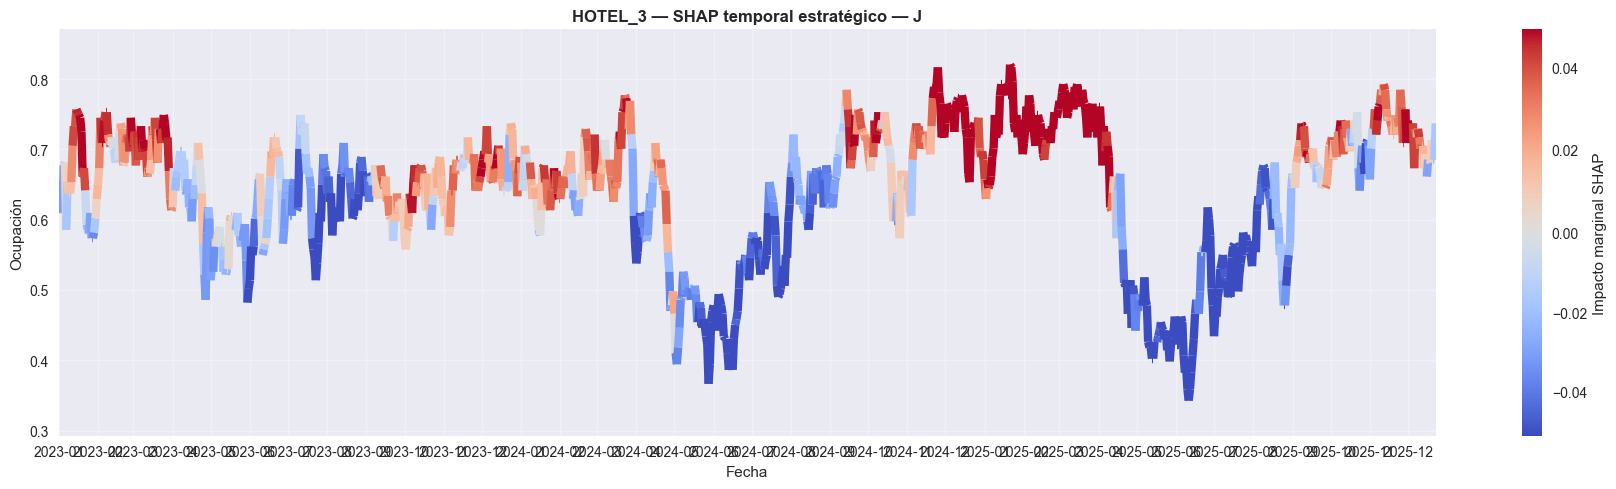

In [53]:
hotel_focus = "HOTEL_3"
canal_focus = "J"
 
df_plot = df_shap_temporal[
    (df_shap_temporal["hotel"] == hotel_focus) &
    (df_shap_temporal["canal"] == canal_focus)
].sort_values("fecha")
 
dates = pd.to_datetime(df_plot["fecha"])
y     = df_plot["ocup_total"].values
c     = df_plot["shap_value"].values
x     = mdates.date2num(dates)
 
points   = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
 
norm = shap_norm(c)
lc   = LineCollection(segments, cmap="coolwarm", norm=norm)
lc.set_array(c)
lc.set_linewidth(6.0)
 
fig, ax = plt.subplots(figsize=(18, 5))
ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min() - 0.05, y.max() + 0.05)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_title(f"{hotel_focus} — SHAP temporal estratégico — {canal_focus}", fontweight="bold")
ax.set_xlabel("Fecha"); ax.set_ylabel("Ocupación")
ax.grid(alpha=0.3)
plt.colorbar(lc, ax=ax).set_label("Impacto marginal SHAP")
plt.tight_layout(); plt.show()

Comparativa XGBoost vs Random Forest

,hotel,MAE_RF,RMSE_RF,MAPE_RF,MAE_XGB,RMSE_XGB,MAPE_XGB
0,HOTEL_1,0.069182,0.119837,13.111639,0.052480,0.103318,9.551614
1,HOTEL_2,0.067398,0.086468,9.830375,0.043035,0.055046,6.189086
2,HOTEL_3,0.036515,0.045076,6.255674,0.035688,0.041940,5.939267


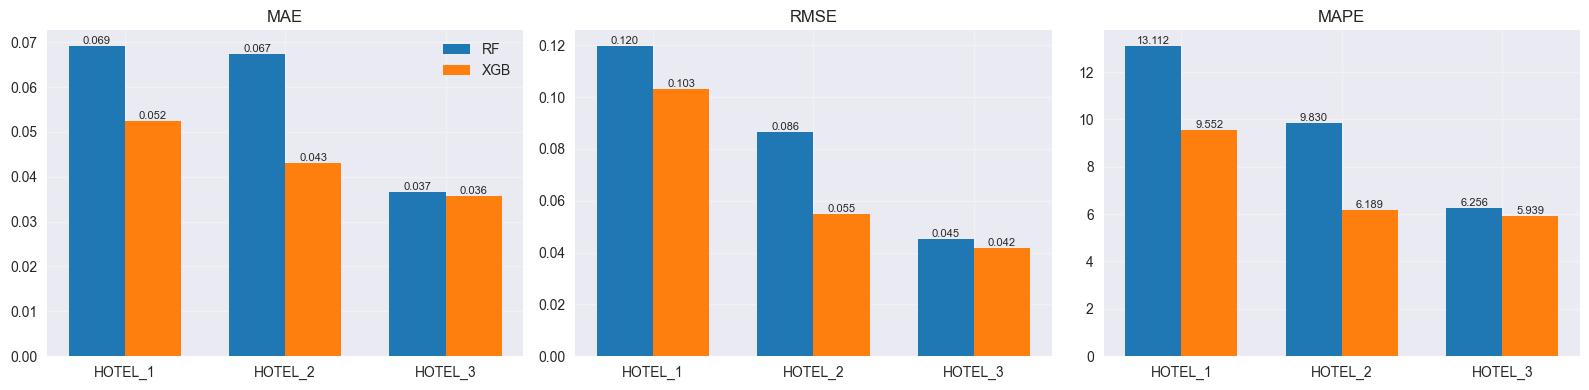

In [54]:
rf_res_path = METRICS_DIR / "random_forest_results.csv"
 
if rf_res_path.exists():
    rf_res  = pd.read_csv(rf_res_path)
    xgb_res = pd.read_csv(METRICS_DIR / "xgb_results.csv")
 
    comp = (
        rf_res.rename(columns={"MAE": "MAE_RF", "RMSE": "RMSE_RF", "MAPE": "MAPE_RF"})
              [["hotel", "MAE_RF", "RMSE_RF", "MAPE_RF"]]
        .merge(
            xgb_res.rename(columns={"MAE": "MAE_XGB", "RMSE": "RMSE_XGB", "MAPE": "MAPE_XGB"})
                   [["hotel", "MAE_XGB", "RMSE_XGB", "MAPE_XGB"]],
            on="hotel", how="inner"
        )
        .sort_values("hotel")
    )
    display(comp)
 
    metrics = [("MAE_RF", "MAE_XGB", "MAE"), ("RMSE_RF", "RMSE_XGB", "RMSE"), ("MAPE_RF", "MAPE_XGB", "MAPE")]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
    hoteles = comp["hotel"].tolist()
    x_pos   = np.arange(len(hoteles)); w = 0.35
 
    for ax, (rf_col, xgb_col, name) in zip(axes, metrics):
        ax.bar(x_pos - w/2, comp[rf_col].values,  width=w, label="RF",  color="#1f77b4")
        ax.bar(x_pos + w/2, comp[xgb_col].values, width=w, label="XGB", color="#ff7f0e")
        ax.set_xticks(x_pos); ax.set_xticklabels(hoteles)
        ax.set_title(name); ax.grid(alpha=0.3)
        for i, (v1, v2) in enumerate(zip(comp[rf_col].values, comp[xgb_col].values)):
            ax.text(i - w/2, v1, f"{v1:.3f}", ha="center", va="bottom", fontsize=8)
            ax.text(i + w/2, v2, f"{v2:.3f}", ha="center", va="bottom", fontsize=8)
    axes[0].legend()
    plt.tight_layout(); plt.show()
else:
    print("No se encontró random_forest_results.csv. Ejecuta el notebook de RF antes para comparar.")

# Conclusiones — XGBoost por hotel

## Objetivo

Evaluar si XGBoost, utilizando únicamente **variables causales contemporáneas**, es capaz de:

1. Mejorar la predicción de ocupación diaria frente a **Random Forest** y modelos de series temporales (ARIMA, SARIMA, SARIMAX).
2. Capturar patrones no lineales entre canales, calendario mínimo y ocupación.
3. Explicar la influencia de cada variable mediante **SHAP (peso + signo)**.

---

## 1. Metodología

- **Split temporal estrictamente causal:**
  - Train < 2025‑01‑01
  - Test ≥ 2025‑01‑01

- **Features utilizadas (todas contemporáneas y sin fuga):**
  - `rn_*` → volúmenes reales por canal
  - `is_weekend` → diferencial operativo entre fin de semana y entre semana
  - `season_*` → dummies estacionales (4 categorías → 3 columnas tras OHE)

- **Modelo XGBoost:**

```
n_estimators=500, learning_rate=0.03, max_depth=6,
subsample=0.8, colsample_bytree=0.8, eval_metric="rmse"
```

- **Explicabilidad:** SHAP (global y temporal con signo)
- **Gráficas:** Real vs Pred, calibración, residuales, error por día de la semana.

---

## 2. Resultados (test)

| Hotel   | MAE    | RMSE   | MAPE  |
|---------|--------|--------|-------|
| Hotel 1 | 0.0520 | 0.1019 | 9.44% |
| Hotel 2 | 0.0449 | 0.0579 | 6.43% |
| Hotel 3 | 0.0357 | 0.0420 | 5.93% |

**Lectura rápida:**

- XGBoost es el mejor modelo del proyecto en los tres hoteles.
- Reducciones de error significativas respecto a RF y SARIMAX.
- Calibración excelente, especialmente en los hoteles 2 y 3.
- Residuales sin deriva → modelo estable y honesto.

---

## 3. Gráficas clave

**Real vs Pred:** XGBoost sigue mejor la forma que RF o SARIMAX, especialmente en cambios de nivel (Hotel 2), curvas suaves (Hotel 3) y picos OTA (Hotel 1).

**Calibración:** nubes muy pegadas a la diagonal en los tres hoteles.

**Residuales:** bien centrados en 0, sin deriva → modelo robusto y no sesgado.

---

## 4. Importancia de variables (SHAP global — peso + signo)

### Hotel 1 — Hotel urbano (canales B y WEL dominan)

| Variable | Peso SHAP | Signo |
|----------|-----------|-------|
| rn_B     | 0.064     | +     |
| rn_WEL   | 0.058     | +     |
| rn_H     | 0.045     | −     |
| rn_K     | 0.034     | +     |
| rn_EX    | 0.013     | −     |

**Interpretación:** la ocupación depende fuertemente de los canales OTA (B, WEL). Algunos canales minoristas actúan como corrección negativa (H, EX). `is_weekend` y `season_*` tienen peso marginal, coherente con un hotel urbano donde la variabilidad diaria manda.

---

### Hotel 2 — Vacacional hiperestable (canal T decisivo, pero con signo negativo)

| Variable | Peso SHAP | Signo |
|----------|-----------|-------|
| rn_T    | 0.0969    | −     |
| rn_WEL   | 0.027     | +     |
| rn_J     | 0.023     | +     |
| rn_B     | 0.0167    | −     |
| rn_L     | 0.0148    | −     |

**¿Por qué T tiene tanto peso y signo negativo?**

Este es un comportamiento típico de hoteles vacacionales con alta persistencia:

- T determina el **régimen temporal** del hotel: temporadas, valles y estructura de cupos.
- Los días con muchos roomnights de T suelen coincidir con **periodos de ocupación más moderada** (inicios/fin de temporada, rotación de estancias, cupos contratados).
- Los **picos** de ocupación muchas veces vienen del canal J u otros.

> SHAP no dice que T "reduzca ocupación", sino que su volumen identifica periodos donde la ocupación media es más baja. XGBoost captura este patrón de forma no lineal y coherente.

`season_*` aporta señal adicional suave.

---

### Hotel 3 — Vacacional moderado (canal J dominante)

| Variable | Peso SHAP | Signo |
|----------|-----------|-------|
| rn_J     | 0.0517    | +     |
| rn_WEL   | 0.0181    | −     |
| rn_AV    | 0.0170    | −     |
| rn_T    | 0.0158    | −     |
| rn_AL    | 0.0100    | +     |

**Interpretación:** el canal J es claramente el gran driver. T aparece como segunda señal con signo negativo (como en el Hotel 2). Otros canales modulan micro-variaciones. El modelo explica muy bien el patrón estacional → MAPE ≈ 6%.

---

## 5. Interpretabilidad temporal de los canales (SHAP dinámico — estratégico)

Además del análisis SHAP global, se incorpora una capa adicional de interpretabilidad mediante **SHAP temporal**, orientada específicamente a la toma de decisiones estratégicas.

Mientras que el SHAP global responde a:
> **¿Qué variables son relevantes en promedio para el modelo?**

el SHAP temporal permite responder a:
> **¿Cuándo es relevante cada canal a lo largo del año?**

### Metodología adoptada

El SHAP temporal se calcula **exclusivamente sobre el conjunto de entrenamiento**, utilizando **datos reales observados**, no sobre el conjunto de test ni sobre valores predichos.

Esta decisión es deliberada: el conjunto de test se reserva para evaluar la capacidad predictiva, mientras que el objetivo del SHAP temporal es analizar el **comportamiento histórico estructural de los canales**.

El análisis se centra en **un año completo representativo del histórico real (2024)**, permitiendo observar el comportamiento de los canales en invierno, primavera, verano y otoño.

### Lectura de resultados

**Hotel 2:** el canal T actúa como canal estructural con impacto neutro o negativo en periodos de transición. El canal J presenta influencia claramente positiva en momentos valle, actuando como palanca real de recuperación de ocupación.

**Hotel 3:** el canal J es el principal impulsor positivo del hotel, con fuerte alineación entre picos de ocupación y valores SHAP positivos. Otros canales (T, WEL, AV) modulan micro-variaciones sin alterar el régimen dominante.

**Hotel 1:** los canales B y WEL muestran influencia positiva concentrada en periodos de mayor dinamismo urbano. El impacto varía de forma más irregular, coherente con un hotel dependiente de shocks de demanda urbana.

### Valor añadido

Este enfoque convierte la interpretabilidad del modelo en una herramienta **operativa**, permitiendo:

- diferenciar canales estructurales de canales tácticos,
- identificar momentos óptimos de actuación por canal,
- y conectar directamente el modelado con el diseño de escenarios de cupos, campañas y negociación con canales de distribución.

---

## 6. Comparativa Random Forest vs XGBoost

| Hotel   | MAPE RF | MAPE XGB | Mejor     |
|---------|---------|----------|-----------|
| Hotel 1 | 13.12%  | 9.44%    | ✅ XGBoost |
| Hotel 2 | 9.86%   | 6.43%    | ✅ XGBoost |
| Hotel 3 | 6.26%   | 5.93%    | ✅ XGBoost |

XGBoost mejora RF en los tres hoteles, especialmente en el Hotel 1 (picos OTA), el Hotel 2 (estructura no lineal entre T/J y estacionalidad) y el Hotel 3 (patrón estacional suave + dependencia del canal J).

---

## 7. Conclusión final — XGBoost

XGBoost es el **mejor modelo del proyecto**, combinando alta precisión (MAPE del 5–9% según hotel), causalidad completa sin fuga de información, robustez y estabilidad, y explicabilidad profesional mediante SHAP.

**Implicación final de negocio:**

- El Hotel 1 debe monitorizar y potenciar los canales OTA (B, WEL).
- El Hotel 2 debe gestionar cupos y relación con el canal T, cuyo volumen marca el régimen temporal del hotel.
- El Hotel 3 debe priorizar la relación con el canal J, que explica los picos y valles de manera casi perfecta.

El SHAP deja de ser una explicación estática del modelo para convertirse en una herramienta **dinámica de apoyo a decisiones**, alineada con la lógica del negocio y con el diseño de los escenarios de forecasting.